Reference time: FCOO=2026-06-26T10:00:00.000000000  CMEMS=2026-06-26T10:00:00.000000000
Target grid: 25 x 20 cells at 0.1 deg
depth=  0.0 m | max|mag diff|=0.199 m/s | max|dir diff|=179.2 deg
depth=  5.0 m | max|mag diff|=0.195 m/s | max|dir diff|=177.9 deg
depth= 20.0 m | max|mag diff|=0.261 m/s | max|dir diff|=179.8 deg
depth= 50.0 m | max|mag diff|=0.259 m/s | max|dir diff|=178.5 deg
Saved fcoo_vs_cmems_diff.png


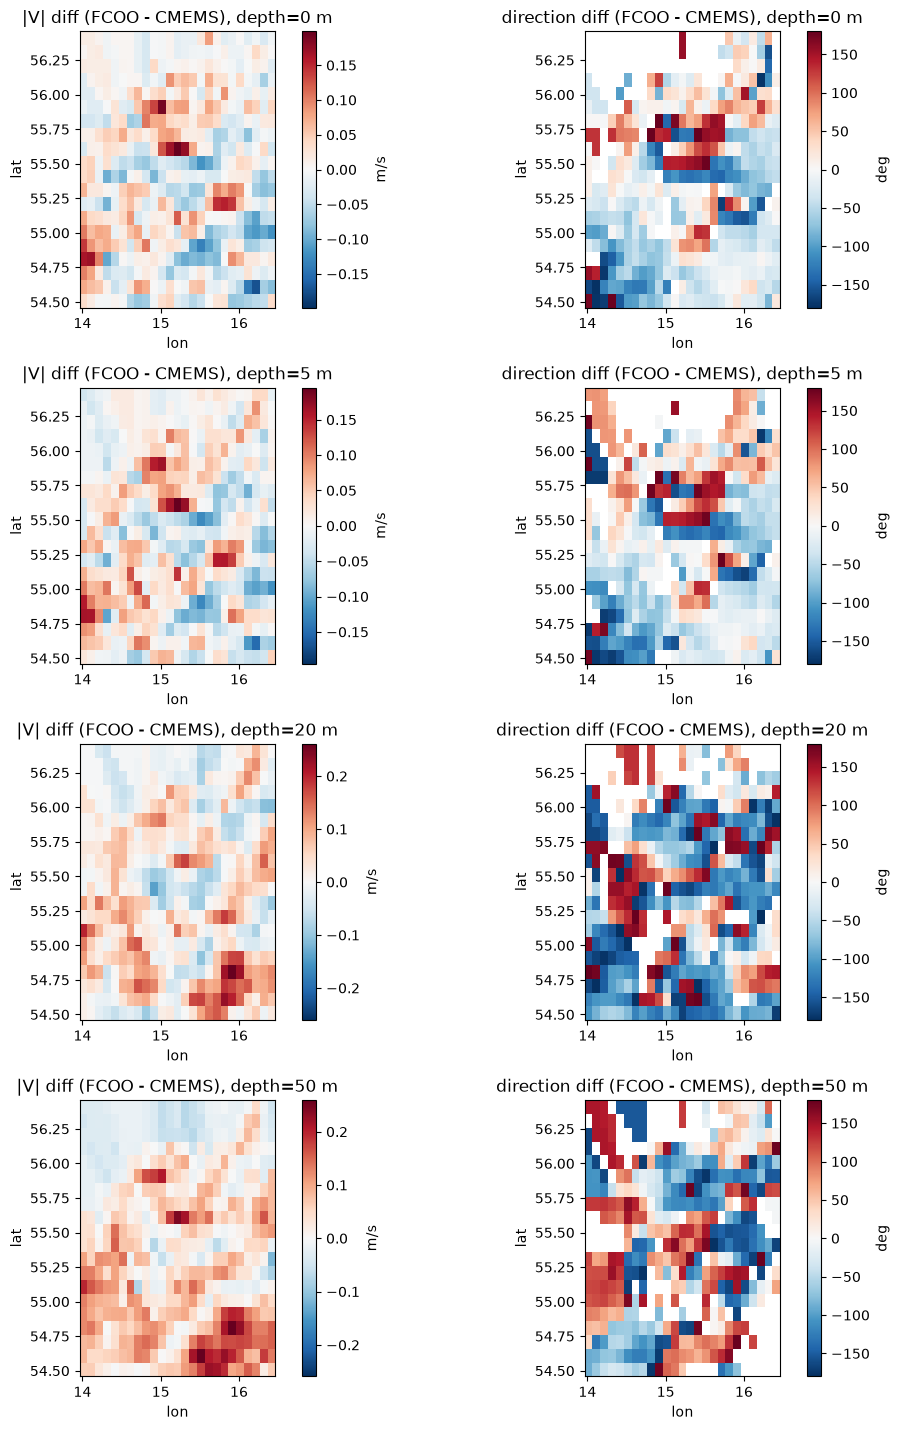

In [3]:
"""
compare_fcoo_cmems.py

Quick-look diagnostic comparing surface-current forecasts from an FCOO/GETM
.nc file against a CMEMS .nc file: for each requested depth, plots the
magnitude difference (|V_fcoo| - |V_cmems|) and the direction difference
(bearing_fcoo - bearing_cmems, wrapped to [-180, 180] deg) on a common,
deliberately coarse lat/lon grid.

Design notes / assumptions (edit the CONFIG block to match your files):
  - FCOO grids are often curvilinear (2D lat/lon). CMEMS grids are usually
    regular (1D lat/lon). This script treats both the same way: it flattens
    each source grid to scattered (lon, lat, value) points, optionally
    subsamples them, and interpolates onto one common coarse target grid
    with scipy.interpolate.griddata. The "coarse" knob is GRID_RES_DEG; the
    "not too much computation" knob is SOURCE_SUBSAMPLE_MAX_POINTS (the cost
    of griddata is driven by the *source* point count, not the target grid,
    so that's the one that actually controls runtime).
  - Depth: both models are interpolated (in the vertical) onto the same
    TARGET_DEPTHS, since native vertical levels rarely match between models.
    Assumes depth coordinates are positive-down in metres; if a file stores
    depth as negative (height), the sign is flipped automatically.
  - Time: the FCOO file's first timestep is used as the reference valid
    time, and the nearest available CMEMS timestep is matched to it. Set
    TARGET_TIME explicitly if you want a specific valid time instead.
  - Direction is undefined when currents are near zero, so direction-diff
    pixels are masked out wherever either model's speed at that point is
    below MIN_SPEED_FOR_DIRECTION.

Run: python compare_fcoo_cmems.py
"""

import numpy as np
import xarray as xr
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ============================ CONFIG ============================
FCOO_FILE = "fcoo_subset.nc"
CMEMS_FILE = "cmems_subset.nc"

# Candidate variable/coord names to auto-detect. Add your own if these
# don't match -- print(xr.open_dataset(path)) once to check.
U_NAMES = ["uo", "u", "uu", "water_u", "eastward_sea_water_velocity"]
V_NAMES = ["vo", "v", "vv", "water_v", "northward_sea_water_velocity"]
LAT_NAMES = ["latitude", "lat", "nav_lat"]
LON_NAMES = ["longitude", "lon", "nav_lon"]
DEPTH_NAMES = ["depth", "lev", "z", "deptho"]
TIME_NAMES = ["time", "Time", "valid_time"]

TARGET_DEPTHS = [0.0, 5.0, 20.0, 50.0]   # metres, positive down
GRID_RES_DEG = 0.1                        # coarse common output grid spacing
SOURCE_SUBSAMPLE_MAX_POINTS = 6000        # cap on source points per griddata call
MIN_SPEED_FOR_DIRECTION = 0.02            # m/s; below this, direction is masked
TARGET_TIME = None                        # None -> FCOO's first timestep
RANDOM_SEED = 0                           # for reproducible subsampling

OUTPUT_FILE = "fcoo_vs_cmems_diff.png"
# ==================================================================


def find_name(ds, candidates, kind):
    for name in candidates:
        if name in ds.variables or name in ds.coords:
            return name
    raise KeyError(
        f"Could not find a {kind} variable in {list(ds.variables)}. "
        f"Tried: {candidates}. Add the real name to the matching *_NAMES list."
    )


def get_lonlat(ds, lat_name, lon_name):
    """Return lon, lat as arrays broadcast to the same (possibly 2D) shape."""
    lat = ds[lat_name].values
    lon = ds[lon_name].values
    if lat.ndim == 1 and lon.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)
    return lon, lat


def fix_depth_sign(da, depth_name):
    depth_vals = da[depth_name].values
    if np.nanmax(depth_vals) <= 0 and np.nanmin(depth_vals) < 0:
        da = da.assign_coords({depth_name: -depth_vals})
    return da


def interp_to_depths(da, depth_name, target_depths):
    """Interpolate onto target_depths, clamping requests outside the
    model's native depth range to the nearest available level (same
    out-of-bounds clamping pattern used elsewhere in the pipeline,
    rather than letting xarray return NaN for extrapolation)."""
    da = fix_depth_sign(da, depth_name)
    da = da.sortby(depth_name)
    d_min, d_max = float(da[depth_name].min()), float(da[depth_name].max())
    clamped = np.clip(target_depths, d_min, d_max)
    return da.interp({depth_name: clamped})


def regrid_layer(values, src_lon, src_lat, tlon, tlat, max_points, rng):
    values = np.asarray(values).ravel()
    src_lon = np.asarray(src_lon).ravel()
    src_lat = np.asarray(src_lat).ravel()

    good = np.isfinite(values) & np.isfinite(src_lon) & np.isfinite(src_lat)
    values, src_lon, src_lat = values[good], src_lon[good], src_lat[good]

    if values.size == 0:
        return np.full(tlon.shape, np.nan)

    if values.size > max_points:
        idx = rng.choice(values.size, size=max_points, replace=False)
        values, src_lon, src_lat = values[idx], src_lon[idx], src_lat[idx]

    pts = np.column_stack([src_lon, src_lat])
    out = griddata(pts, values, (tlon, tlat), method="linear")

    nan_mask = np.isnan(out)
    if nan_mask.any():
        out_nearest = griddata(pts, values, (tlon, tlat), method="nearest")
        out[nan_mask] = out_nearest[nan_mask]
    return out


def bearing_deg(u, v):
    """Compass bearing (deg clockwise from North) the current flows toward."""
    return (90.0 - np.degrees(np.arctan2(v, u))) % 360.0


def angle_diff(a, b):
    """Smallest signed difference a-b, wrapped to [-180, 180] deg."""
    return (a - b + 180.0) % 360.0 - 180.0


def main():
    rng = np.random.default_rng(RANDOM_SEED)

    fcoo = xr.open_dataset(FCOO_FILE)
    cmems = xr.open_dataset(CMEMS_FILE)

    u_name_f, v_name_f = find_name(fcoo, U_NAMES, "u"), find_name(fcoo, V_NAMES, "v")
    lat_name_f, lon_name_f = find_name(fcoo, LAT_NAMES, "lat"), find_name(fcoo, LON_NAMES, "lon")
    depth_name_f = find_name(fcoo, DEPTH_NAMES, "depth")
    time_name_f = find_name(fcoo, TIME_NAMES, "time")

    u_name_c, v_name_c = find_name(cmems, U_NAMES, "u"), find_name(cmems, V_NAMES, "v")
    lat_name_c, lon_name_c = find_name(cmems, LAT_NAMES, "lat"), find_name(cmems, LON_NAMES, "lon")
    depth_name_c = find_name(cmems, DEPTH_NAMES, "depth")
    time_name_c = find_name(cmems, TIME_NAMES, "time")

    # --- pick matching valid time ---
    ref_time = fcoo[time_name_f].values[0] if TARGET_TIME is None else np.datetime64(TARGET_TIME)
    fcoo_t = fcoo.sel({time_name_f: ref_time}, method="nearest")
    cmems_t = cmems.sel({time_name_c: ref_time}, method="nearest")
    actual_f_time = fcoo_t[time_name_f].values
    actual_c_time = cmems_t[time_name_c].values
    print(f"Reference time: FCOO={actual_f_time}  CMEMS={actual_c_time}")

    # --- vertical interpolation onto common target depths ---
    u_f_da = interp_to_depths(fcoo_t[u_name_f], depth_name_f, TARGET_DEPTHS)
    v_f_da = interp_to_depths(fcoo_t[v_name_f], depth_name_f, TARGET_DEPTHS)
    u_c_da = interp_to_depths(cmems_t[u_name_c], depth_name_c, TARGET_DEPTHS)
    v_c_da = interp_to_depths(cmems_t[v_name_c], depth_name_c, TARGET_DEPTHS)

    # --- horizontal coords ---
    lon_f, lat_f = get_lonlat(fcoo_t, lat_name_f, lon_name_f)
    lon_c, lat_c = get_lonlat(cmems_t, lat_name_c, lon_name_c)

    # --- common coarse target grid (intersection of both domains) ---
    lon_min = max(np.nanmin(lon_f), np.nanmin(lon_c))
    lon_max = min(np.nanmax(lon_f), np.nanmax(lon_c))
    lat_min = max(np.nanmin(lat_f), np.nanmin(lat_c))
    lat_max = min(np.nanmax(lat_f), np.nanmax(lat_c))
    if lon_min >= lon_max or lat_min >= lat_max:
        raise ValueError("FCOO and CMEMS domains do not overlap -- check lon/lat ranges.")

    target_lon = np.arange(lon_min, lon_max, GRID_RES_DEG)
    target_lat = np.arange(lat_min, lat_max, GRID_RES_DEG)
    tlon, tlat = np.meshgrid(target_lon, target_lat)
    print(f"Target grid: {tlon.shape[1]} x {tlon.shape[0]} cells at {GRID_RES_DEG} deg")

    n_depths = len(TARGET_DEPTHS)
    fig, axes = plt.subplots(
        n_depths, 2, figsize=(11, 3.6 * n_depths), squeeze=False
    )

    aspect = 1.0 / np.cos(np.radians(np.nanmean([lat_min, lat_max])))

    for di, depth in enumerate(TARGET_DEPTHS):
        u_f = regrid_layer(u_f_da.isel({depth_name_f: di}).values, lon_f, lat_f, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        v_f = regrid_layer(v_f_da.isel({depth_name_f: di}).values, lon_f, lat_f, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        u_c = regrid_layer(u_c_da.isel({depth_name_c: di}).values, lon_c, lat_c, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        v_c = regrid_layer(v_c_da.isel({depth_name_c: di}).values, lon_c, lat_c, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)

        mag_f, mag_c = np.hypot(u_f, v_f), np.hypot(u_c, v_c)
        mag_diff = mag_f - mag_c

        dir_f, dir_c = bearing_deg(u_f, v_f), bearing_deg(u_c, v_c)
        dir_diff = angle_diff(dir_f, dir_c)
        weak = (mag_f < MIN_SPEED_FOR_DIRECTION) | (mag_c < MIN_SPEED_FOR_DIRECTION)
        dir_diff = np.where(weak, np.nan, dir_diff)

        print(
            f"depth={depth:>5.1f} m | max|mag diff|={np.nanmax(np.abs(mag_diff)):.3f} m/s "
            f"| max|dir diff|={np.nanmax(np.abs(dir_diff)) if np.any(~np.isnan(dir_diff)) else float('nan'):.1f} deg"
        )

        # --- magnitude difference panel ---
        ax = axes[di, 0]
        vmax_mag = np.nanmax(np.abs(mag_diff))
        vmax_mag = vmax_mag if vmax_mag > 0 else 1e-3
        im = ax.pcolormesh(
            tlon, tlat, mag_diff, cmap="RdBu_r",
            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_mag, vmax=vmax_mag),
            shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"|V| diff (FCOO - CMEMS), depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig.colorbar(im, ax=ax, label="m/s")

        # --- direction difference panel ---
        ax = axes[di, 1]
        im = ax.pcolormesh(
            tlon, tlat, dir_diff, cmap="RdBu_r",
            norm=TwoSlopeNorm(vcenter=0, vmin=-180, vmax=180),
            shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"direction diff (FCOO - CMEMS), depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig.colorbar(im, ax=ax, label="deg")

    fig.tight_layout()
    fig.savefig(OUTPUT_FILE, dpi=150, bbox_inches="tight")
    print(f"Saved {OUTPUT_FILE}")


if __name__ == "__main__":
    main()

In [1]:
"""
data_handler.py
================
All external data acquisition for the CMEMS/FCOO leaderboard.

FCOO data is accessed via OPeNDAP (pydap) -- two products:
    fcoo_idk -- 600 m inner-Danish grid  (idk-600m_3D-velocities_surface)
    fcoo_dk  -- 1 nm North Sea + Baltic  (nsbalt-1nm_velocities_surface)

Chunked pydap requests (~8 timesteps each) replace the previous single
1.85 GB HTTP download, which was reliably dropped by the server on
GitHub Actions runners (Azure data-centre IPs).

All returned datasets follow a standard schema so the rest of the
pipeline never needs to know which model it's working with:
    dims : time, depth, lat, lon
    vars : u, v  (m/s, eastward / northward)

depth has two levels [0, 2000] m with identical surface velocities at
both -- this keeps build_interpolators (RegularGridInterpolator) in-bounds
for all queried depths rather than returning fill_value=0 for depth
queries that exceed a singleton axis.
"""

from __future__ import annotations

import logging
import re
import time
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import requests
import xarray as xr

logger = logging.getLogger(__name__)


# --------------------------------------------------------------------------- #
# Config
# --------------------------------------------------------------------------- #

@dataclass(frozen=True)
class Region:
    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float


MODELS = ("cmems", "fcoo_dk", "fcoo_idk")

CMEMS_DATASET_ID = "cmems_mod_bal_phy_anfc_PT1H-i_202411"
CMEMS_DEPTH_MAX  = 200.0   # metres -- floats don't go deeper in the Baltic

FCOO_BASE        = "https://data.fcoo.dk/webmap/v2/data/FCOO/GETM/"
FCOO_KNOTS_TO_MS = 0.514444
FCOO_FILL        = -9999.0

# OPeNDAP product prefix for each model key
_FCOO_PREFIX = {
    "fcoo_idk": "idk-600m_3D-velocities_surface",
    "fcoo_dk":  "nsbalt-1nm_velocities_surface",
}

# Browser User-Agent so institutional servers don't block the requests
_BROWSER_UA = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/124.0.0.0 Safari/537.36"
)

GDAC_HTTP      = "https://data-argo.ifremer.fr"
ARGO_CACHE_DIR = Path("data/argo_cache")


# --------------------------------------------------------------------------- #
# 1. Model current fields
# --------------------------------------------------------------------------- #

def download_model_data(
    model: str,
    region: Region,
    issue_time: Optional[datetime] = None,
    end_time: Optional[datetime] = None,
) -> xr.Dataset:
    """
    Pull the latest forecast for `model` over `region`.

    issue_time / end_time: optional start/end window passed to the CMEMS
    subsetting API to avoid downloading the full archive.  FCOO ignores them
    (the file on the server already covers a fixed window).

    Returns an xr.Dataset with:
        dims : time, depth, lat, lon
        vars : u (m/s eastward), v (m/s northward)
    Does NOT trim -- caller must call trim_to_forecast_only() first.
    """
    if model == "cmems":
        return _fetch_cmems(region, issue_time, end_time)
    elif model in _FCOO_PREFIX:
        return _fetch_fcoo(model, region)
    else:
        raise ValueError(f"Unknown model {model!r}. Expected one of {MODELS}")


def trim_to_forecast_only(model_data: xr.Dataset, issue_time: datetime) -> xr.Dataset:
    """Drop every timestamp at-or-before issue_time (keep strict future only)."""
    issue_np = np.datetime64(issue_time.replace(tzinfo=None), "ns")
    return model_data.sel(time=model_data.time > issue_np)


# -- CMEMS -------------------------------------------------------------------

def _fetch_cmems(
    region: Region,
    issue_time: Optional[datetime],
    end_time: Optional[datetime] = None,
) -> xr.Dataset:
    """
    Download a CMEMS subset to a local NetCDF4 file, then load it into memory.

    Uses copernicusmarine.subset() (a single HTTP download) instead of
    open_dataset() (hundreds of parallel dask/zarr chunk requests).  The
    single-stream download is faster on CI runners, avoids connection-pool
    exhaustion, and sidesteps the Python 3.14 + dask SIGSEGV.

    Spatial grid is subsampled 2x after loading (stride-indexed reads, so
    only ~2.5 GB is pulled into memory rather than ~10 GB for the full grid).
    """
    import copernicusmarine
    import tempfile
    import os

    kwargs: dict = dict(
        dataset_id=CMEMS_DATASET_ID,
        variables=["uo", "vo"],
        minimum_latitude=region.lat_min,
        maximum_latitude=region.lat_max,
        minimum_longitude=region.lon_min,
        maximum_longitude=region.lon_max,
        minimum_depth=0.52,
        maximum_depth=CMEMS_DEPTH_MAX,
        output_filename="cmems_subset.nc",
    )
    if issue_time is not None:
        kwargs["start_datetime"] = issue_time.strftime("%Y-%m-%dT%H:%M:%S")
    if end_time is not None:
        kwargs["end_datetime"] = end_time.strftime("%Y-%m-%dT%H:%M:%S")

    with tempfile.TemporaryDirectory() as tmp_dir:
        kwargs["output_directory"] = tmp_dir
        tmp_path = os.path.join(tmp_dir, "cmems_subset.nc")

        logger.info("Downloading CMEMS subset (single-stream)…")
        copernicusmarine.subset(**kwargs)
        logger.info("CMEMS subset downloaded, loading into memory")

        # Open without dask -- file-backed lazy reads via xarray+netCDF4.
        # isel with a slice does a strided read from the file so peak memory
        # is only the subsampled shape, not the full spatial grid.
        ds = xr.open_dataset(tmp_path, chunks=None, mask_and_scale=True)

        lat_dim = "latitude" if "latitude" in ds.dims else "lat"
        lon_dim = "longitude" if "longitude" in ds.dims else "lon"
        ds = ds.isel(**{lat_dim: slice(None, None, 2), lon_dim: slice(None, None, 2)})

        rename = {}
        for old, new in [("uo", "u"), ("vo", "v"), ("latitude", "lat"), ("longitude", "lon")]:
            if old in ds:
                rename[old] = new
        ds = ds.rename(rename) if rename else ds

        # Force into a plain in-memory Dataset (no file handles) before the
        # temp directory is deleted.  copy=False avoids a ~2 GB transient
        # duplicate since CMEMS already stores uo/vo as float32.
        return xr.Dataset(
            {
                "u": (["time", "depth", "lat", "lon"], ds["u"].values.astype(np.float32, copy=False)),
                "v": (["time", "depth", "lat", "lon"], ds["v"].values.astype(np.float32, copy=False)),
            },
            coords={
                "time":  ds["time"].values,
                "depth": ds["depth"].values.astype(np.float64),
                "lat":   ds["lat"].values.astype(np.float64),
                "lon":   ds["lon"].values.astype(np.float64),
            },
        )


# -- FCOO (OPeNDAP) ----------------------------------------------------------

_fcoo_ds_cache: dict[str, xr.Dataset] = {}


def _fetch_fcoo(model: str, region: Region) -> xr.Dataset:
    """Download the requested FCOO grid via OPeNDAP and return a pipeline Dataset."""
    if model not in _fcoo_ds_cache:
        files = _list_getm_files()
        if model == "fcoo_idk":
            _fcoo_ds_cache[model] = _fetch_fcoo_idk(files, region)
        else:
            _fcoo_ds_cache[model] = _fetch_fcoo_nsbalt(files, region)
    return _fcoo_ds_cache[model]


def _list_getm_files() -> list[str]:
    """Scrape the FCOO GETM directory for available NetCDF filenames."""
    resp = requests.get(FCOO_BASE, timeout=20, headers={"User-Agent": _BROWSER_UA})
    resp.raise_for_status()
    # hrefs end in .nc.html; extract just the .nc filename
    return re.findall(r'([^\s/"]+\.nc)\.html', resp.text)


def _latest_getm_file(files: list[str], prefix: str) -> str | None:
    """Return the filename with the newest run timestamp for a given product prefix."""
    matches = [f for f in files if f.startswith(prefix)]
    if not matches:
        return None

    def _ts(name: str) -> datetime:
        m = re.search(r"_(\d{10})\.nc$", name)
        return datetime.strptime(m.group(1), "%Y%m%d%H") if m else datetime.min

    return max(matches, key=_ts)


def _fetch_coords_1d(fname: str, *varnames: str) -> dict[str, np.ndarray]:
    """Fetch 1-D coordinate arrays from the OPeNDAP .ascii endpoint."""
    url = FCOO_BASE + fname + ".ascii?" + ",".join(varnames)
    r = requests.get(url, timeout=30, headers={"User-Agent": _BROWSER_UA})
    r.raise_for_status()

    coords: dict[str, np.ndarray] = {}
    current_var: str | None = None
    vals: list[float] = []
    for line in r.text.split("\n"):
        line = line.strip()
        if line in varnames:
            if current_var and vals:
                coords[current_var] = np.array(vals)
            current_var = line
            vals = []
        elif line.startswith("[") and current_var:
            vals.append(float(line.split("]", 1)[1].strip()))
    if current_var and vals:
        coords[current_var] = np.array(vals)
    return coords


def _fetch_time_coord(fname: str) -> np.ndarray:
    """
    Fetch the time coordinate from OPeNDAP .ascii and return as datetime64[s].
    Trims zero-padded trailing slots (FCOO NetCDF3 preallocates 56 slots but
    only writes the filled prefix).
    """
    coords = _fetch_coords_1d(fname, "time")
    t_raw = coords.get("time", np.array([]))
    if not len(t_raw):
        return t_raw

    # Parse epoch string from .das metadata
    das = requests.get(
        FCOO_BASE + fname + ".das", timeout=15, headers={"User-Agent": _BROWSER_UA}
    ).text
    m = re.search(r'units\s+"seconds since (\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"', das)
    if not m:
        raise RuntimeError(f"Cannot parse time units from {FCOO_BASE + fname}.das")
    epoch = np.datetime64(m.group(1).replace(" ", "T"), "s")

    # Drop zero-padded trailing slots (raw value 0 repeats the epoch timestamp)
    diffs = np.diff(t_raw)
    n_valid = int(np.argmax(diffs <= 0)) + 1 if (diffs <= 0).any() else len(t_raw)
    return epoch + t_raw[:n_valid].astype("timedelta64[s]")


def _pydap_open(fname: str):
    from pydap.client import open_url
    return open_url(FCOO_BASE + fname)


def _fetch_variable_chunked(
    fname: str,
    varname: str,
    lat0: int, lat1: int,
    lon0: int, lon1: int,
    chunk_size: int = 8,
    max_retries: int = 5,
) -> np.ndarray:
    """
    Fetch a (time, lat, lon) variable via pydap in time chunks of chunk_size.
    Each chunk is retried independently with exponential backoff and a fresh
    OPeNDAP connection on retry, so a dropped connection never aborts the
    whole download.
    """
    ds  = _pydap_open(fname)
    var = ds[varname]
    n_time = var.shape[0]
    chunks = []

    for t_start in range(0, n_time, chunk_size):
        t_end = min(t_start + chunk_size - 1, n_time - 1)
        for attempt in range(max_retries):
            try:
                raw = var[t_start:t_end + 1, lat0:lat1 + 1, lon0:lon1 + 1]
                chunks.append(np.asarray(raw.data).astype(np.float32))
                logger.debug("  %s t[%d:%d] ok", varname, t_start, t_end)
                break
            except Exception as exc:
                if attempt == max_retries - 1:
                    raise
                wait = 5 * 2 ** attempt   # 5 s, 10 s, 20 s, 40 s
                logger.warning(
                    "  %s t[%d:%d] attempt %d failed (%s), retry in %ds",
                    varname, t_start, t_end, attempt + 1, exc, wait,
                )
                time.sleep(wait)
                ds  = _pydap_open(fname)  # fresh connection
                var = ds[varname]

    return np.concatenate(chunks, axis=0)


def _build_fcoo_dataset(
    uu: np.ndarray,
    vv: np.ndarray,
    latc: np.ndarray,
    lonc: np.ndarray,
    times: np.ndarray,
) -> xr.Dataset:
    """
    Package uu/vv arrays into the pipeline's standard (time, depth, lat, lon) schema.

    depth = [0, 2000] m with surface velocities duplicated at both levels.
    RegularGridInterpolator then returns the surface current at any queried
    depth (interpolating between two equal values) rather than returning
    fill_value=0 for out-of-bounds depth queries.
    """
    u = np.where(uu == FCOO_FILL, np.nan, uu).astype(np.float32) * FCOO_KNOTS_TO_MS
    v = np.where(vv == FCOO_FILL, np.nan, vv).astype(np.float32) * FCOO_KNOTS_TO_MS

    # Duplicate surface layer on depth axis: (time, lat, lon) -> (time, 2, lat, lon)
    u2 = np.stack([u, u], axis=1)
    v2 = np.stack([v, v], axis=1)

    return xr.Dataset(
        {"u": (["time", "depth", "lat", "lon"], u2),
         "v": (["time", "depth", "lat", "lon"], v2)},
        coords={
            "time":  times,
            "depth": np.array([0.0, 2000.0]),
            "lat":   latc.astype(np.float64),
            "lon":   lonc.astype(np.float64),
        },
    )


def _fetch_fcoo_idk(files: list[str], region: Region) -> xr.Dataset:
    """Fetch IDK (600 m inner-Danish) surface velocities via OPeNDAP."""
    fname = _latest_getm_file(files, _FCOO_PREFIX["fcoo_idk"])
    if fname is None:
        raise RuntimeError(f"No IDK velocity file found at {FCOO_BASE}")
    logger.info("FCOO IDK: %s", fname)

    coords = _fetch_coords_1d(fname, "latc", "lonc")
    latc, lonc = coords["latc"], coords["lonc"]
    times = _fetch_time_coord(fname)
    n_t = len(times)

    lat_idx = np.where((latc >= region.lat_min) & (latc <= region.lat_max))[0]
    lon_idx = np.where((lonc >= region.lon_min) & (lonc <= region.lon_max))[0]
    if not lat_idx.size or not lon_idx.size:
        raise RuntimeError("IDK grid has no points inside the pipeline region")
    lat0, lat1 = int(lat_idx[0]), int(lat_idx[-1])
    lon0, lon1 = int(lon_idx[0]), int(lon_idx[-1])

    logger.info("IDK subset: %d lat × %d lon, %d timesteps",
                lat1 - lat0 + 1, lon1 - lon0 + 1, n_t)

    uu = _fetch_variable_chunked(fname, "uu", lat0, lat1, lon0, lon1)[:n_t]
    vv = _fetch_variable_chunked(fname, "vv", lat0, lat1, lon0, lon1)[:n_t]

    return _build_fcoo_dataset(uu, vv, latc[lat0:lat1 + 1], lonc[lon0:lon1 + 1], times)


def _fetch_fcoo_nsbalt(files: list[str], region: Region) -> xr.Dataset:
    """
    Fetch NSBALT (1 nm North Sea + Baltic) surface velocities via OPeNDAP.
    Subsets to region before downloading; chunked to keep each request small.
    """
    fname = _latest_getm_file(files, _FCOO_PREFIX["fcoo_dk"])
    if fname is None:
        raise RuntimeError(f"No NSBALT velocity file found at {FCOO_BASE}")
    logger.info("FCOO NSBALT: %s", fname)

    coords = _fetch_coords_1d(fname, "latc", "lonc")
    latc, lonc = coords["latc"], coords["lonc"]
    times = _fetch_time_coord(fname)
    n_t = len(times)

    lat_idx = np.where((latc >= region.lat_min) & (latc <= region.lat_max))[0]
    lon_idx = np.where((lonc >= region.lon_min) & (lonc <= region.lon_max))[0]
    if not lat_idx.size or not lon_idx.size:
        raise RuntimeError("NSBALT grid has no points inside the pipeline region")
    lat0, lat1 = int(lat_idx[0]), int(lat_idx[-1])
    lon0, lon1 = int(lon_idx[0]), int(lon_idx[-1])

    n_lat, n_lon = lat1 - lat0 + 1, lon1 - lon0 + 1
    frac = (n_lat * n_lon) / (len(latc) * len(lonc))
    logger.info("NSBALT subset: %d lat × %d lon (%.0f%% of grid), %d timesteps",
                n_lat, n_lon, frac * 100, n_t)

    uu = _fetch_variable_chunked(fname, "uu", lat0, lat1, lon0, lon1)[:n_t]
    vv = _fetch_variable_chunked(fname, "vv", lat0, lat1, lon0, lon1)[:n_t]

    return _build_fcoo_dataset(uu, vv, latc[lat0:lat1 + 1], lonc[lon0:lon1 + 1], times)


# --------------------------------------------------------------------------- #
# 2. Argo domain pull
# --------------------------------------------------------------------------- #

@dataclass(frozen=True)
class ArgoPull:
    float_id: str
    last_position: tuple[float, float]   # (lat, lon)
    last_time: datetime
    traj_path: Path                      # set by download_float_history, not here


def download_argo_floats_in_domain(region: Region) -> dict[str, ArgoPull]:
    """
    Pull every float currently reporting within `region` over the last 60 days.
    Returns {float_id: ArgoPull} keyed by WMO string.
    """
    import argopy

    end   = datetime.now(tz=timezone.utc)
    start = end - timedelta(days=60)

    fetcher = argopy.DataFetcher(src="gdac").region([
        region.lon_min, region.lon_max,
        region.lat_min, region.lat_max,
        0, 2000,
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d"),
    ])

    try:
        ds = fetcher.to_xarray()
    except Exception as exc:
        logger.warning("argopy region fetch failed: %s", exc)
        return {}

    if "PLATFORM_NUMBER" not in ds:
        return {}

    platform_raw = ds["PLATFORM_NUMBER"].values
    try:
        platform_strs = np.array([
            v.decode().strip() if isinstance(v, bytes) else str(v).strip()
            for v in platform_raw
        ])
    except Exception:
        platform_strs = platform_raw.astype(str)

    times = pd.to_datetime(ds["TIME"].values)
    lats  = ds["LATITUDE"].values.astype(float)
    lons  = ds["LONGITUDE"].values.astype(float)

    result: dict[str, ArgoPull] = {}
    for wmo in np.unique(platform_strs):
        mask  = platform_strs == wmo
        valid = mask & ~np.isnan(lats) & ~np.isnan(lons) & pd.notna(times)
        if not valid.any():
            continue
        idx = np.where(valid)[0][int(np.argmax(times[valid]))]
        result[wmo] = ArgoPull(
            float_id=wmo,
            last_position=(float(lats[idx]), float(lons[idx])),
            last_time=times[idx].to_pydatetime().replace(tzinfo=None),
            traj_path=Path(),
        )
    return result


# --------------------------------------------------------------------------- #
# 3. Full history pull
# --------------------------------------------------------------------------- #

def download_float_history(
    float_id: str,
    cache_dir: Path = ARGO_CACHE_DIR,
) -> Path:
    """
    Download Rtraj.nc (and _prof.nc) for float_id from the GDAC HTTP mirror.
    Returns local Rtraj.nc path; files are cached.
    """
    cache_dir  = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    rtraj_path = cache_dir / f"{float_id}_Rtraj.nc"

    if rtraj_path.exists():
        return rtraj_path

    dac      = _find_dac(float_id)
    base_url = f"{GDAC_HTTP}/dac/{dac}/{float_id}"

    for fname in (f"{float_id}_Rtraj.nc", f"{float_id}_prof.nc"):
        url   = f"{base_url}/{fname}"
        local = cache_dir / fname
        if local.exists():
            continue
        for attempt in range(2):
            try:
                r = requests.get(url, timeout=120, stream=True)
                r.raise_for_status()
                with open(local, "wb") as fh:
                    for chunk in r.iter_content(1 << 20):
                        fh.write(chunk)
                logger.info("Downloaded %s -> %s", url, local)
                break
            except requests.HTTPError as exc:
                logger.warning("Could not fetch %s: %s", url, exc)
                break  # 4xx/5xx won't improve on retry
            except requests.ConnectionError as exc:
                if attempt == 0:
                    logger.warning("Connection error fetching %s, retrying: %s", url, exc)
                else:
                    logger.warning("Connection error fetching %s (gave up): %s", url, exc)

    if not rtraj_path.exists():
        raise FileNotFoundError(
            f"Rtraj not found for float {float_id} (DAC={dac}). "
            f"Check {GDAC_HTTP}/dac/{dac}/{float_id}/"
        )
    return rtraj_path


def _find_dac(float_id: str) -> str:
    """Look up the float's DAC in the argopy Argo index."""
    import argopy

    try:
        idx = argopy.ArgoIndex(src="gdac")
        idx.load()
        df  = idx.to_dataframe()
        rows = df[df["wmo"] == int(float_id)]
        if rows.empty:
            raise ValueError(f"Float {float_id} not in Argo index")
        # 'dac' column is present; fall back to parsing 'file' if absent
        if "dac" in rows.columns:
            return str(rows["dac"].iloc[0])
        return rows["file"].iloc[0].split("/")[0]
    except Exception as exc:
        raise RuntimeError(f"Could not find DAC for float {float_id}: {exc}") from exc


In [2]:
"""
fetch_for_comparison.py

Pulls one CMEMS and one FCOO dataset via data_handler.py and saves each as
a standalone .nc file, ready to feed straight into compare_fcoo_cmems.py.

Both datasets already share the pipeline's standard schema
(dims: time, depth, lat, lon; vars: u, v), so this is mostly plumbing --
no renaming or reshaping needed.

IMPORTANT CAVEAT before you read the comparison output:
FCOO's depth axis here is just [0, 2000] m with the *surface* value
duplicated at both levels (see _build_fcoo_dataset in data_handler.py --
it's a deliberate hack to keep RegularGridInterpolator in-bounds, not real
vertical structure). CMEMS, on the other hand, has genuine depth levels
down to CMEMS_DEPTH_MAX (200 m). So if you run compare_fcoo_cmems.py with
TARGET_DEPTHS = [0, 20, 50, ...], the FCOO side of every depth below the
surface is just the surface current repeated -- you are not comparing
"FCOO at 20m vs CMEMS at 20m", you're comparing "FCOO's surface estimate
vs CMEMS's real subsurface profile". That might be exactly the comparison
you want (e.g. "how much does subsurface flow diverge from the
surface-only FCOO proxy"), but it is NOT a true depth-resolved model
intercomparison. Worth deciding which question you're actually asking
before drawing conclusions from the deeper panels.
"""

from datetime import datetime, timezone


# ============================ CONFIG ============================
# Bornholm Basin box, around WMO 4903784 -- edit to whatever region
# you actually want to compare.
REGION = Region(lat_min=54.5, lat_max=56.5, lon_min=14.0, lon_max=16.5)

FCOO_MODEL = "fcoo_dk"      # "fcoo_dk" (1nm North Sea+Baltic) or "fcoo_idk" (600m inner-Danish)

# None -> use right now (UTC) as the forecast issue time.
ISSUE_TIME: datetime | None = None

# If True, drop every timestep at-or-before ISSUE_TIME (matches how the
# pipeline normally consumes this data -- forecast horizon only). Set
# False if you want the full available window instead, e.g. to include
# already-elapsed timesteps in the comparison.
TRIM_TO_FORECAST_ONLY = True

CMEMS_OUT = "cmems_subset.nc"
FCOO_OUT = "fcoo_subset.nc"
# ==================================================================


def main():
    issue_time = ISSUE_TIME or datetime.now(timezone.utc)

    print(f"Fetching CMEMS over {REGION}...")
    cmems_ds = download_model_data("cmems", REGION, issue_time=issue_time)
    if TRIM_TO_FORECAST_ONLY:
        cmems_ds = trim_to_forecast_only(cmems_ds, issue_time)
    cmems_ds.to_netcdf(CMEMS_OUT)
    print(f"Saved {CMEMS_OUT}: sizes={dict(cmems_ds.sizes)}")

    print(f"Fetching FCOO ({FCOO_MODEL}) over {REGION}...")
    fcoo_ds = download_model_data(FCOO_MODEL, REGION)
    if TRIM_TO_FORECAST_ONLY:
        fcoo_ds = trim_to_forecast_only(fcoo_ds, issue_time)
    fcoo_ds.to_netcdf(FCOO_OUT)
    print(f"Saved {FCOO_OUT}: sizes={dict(fcoo_ds.sizes)}")

    print(
        "\nDone. Point compare_fcoo_cmems.py's FCOO_FILE/CMEMS_FILE at "
        f"{FCOO_OUT!r} and {CMEMS_OUT!r}. Both already use 'u'/'v'/'lat'/'lon'/"
        "'depth' naming, so its auto-detection will pick them up with no edits."
    )


if __name__ == "__main__":
    main()

Fetching CMEMS over Region(lat_min=54.5, lat_max=56.5, lon_min=14.0, lon_max=16.5)...


/home/ddyob/Documents/argo_piloting/model_tracker/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING - 2026-06-26T09:20:06Z - The dataset version has been included in the dataset_id argument. This is not recommended. Please either omit the version —allowing the Toolbox to select it automatically— or specify it using the dataset_version argument.
INFO - 2026-06-26T09:20:08Z - Selected dataset version: "202411"
INFO - 2026-06-26T09:20:08Z - Selected dataset part: "default"
WARNING - 2026-06-26T09:20:08Z - The dataset cmems_mod_bal_phy_anfc_PT1H-i, version '202411', part 'default' is currently being updated. Data after 2026-06-25T12:00:00.000Z may not be up to date.
/home/ddyob/Documents/argo_piloting/model_tracker/.venv/bin/python: No module named pip
100%|██████████| [09:29<00:00]  
INFO - 202

Saved cmems_subset.nc: sizes={'time': 207, 'depth': 32, 'lat': 60, 'lon': 45}
Fetching FCOO (fcoo_dk) over Region(lat_min=54.5, lat_max=56.5, lon_min=14.0, lon_max=16.5)...


/home/ddyob/Documents/argo_piloting/model_tracker/.venv/lib/python3.12/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


Saved fcoo_subset.nc: sizes={'time': 45, 'depth': 2, 'lat': 120, 'lon': 90}

Done. Point compare_fcoo_cmems.py's FCOO_FILE/CMEMS_FILE at 'fcoo_subset.nc' and 'cmems_subset.nc'. Both already use 'u'/'v'/'lat'/'lon'/'depth' naming, so its auto-detection will pick them up with no edits.


Reference time: FCOO=2026-06-26T10:00:00.000000000  CMEMS=2026-06-26T10:00:00.000000000
Target grid: 82 x 66 cells at 0.03 deg
depth=  0.0 m | max|mag diff|=0.213 m/s | max|dir diff|=179.8 deg
depth=  5.0 m | max|mag diff|=0.218 m/s | max|dir diff|=180.0 deg
depth= 20.0 m | max|mag diff|=0.269 m/s | max|dir diff|=180.0 deg
depth= 50.0 m | max|mag diff|=0.268 m/s | max|dir diff|=180.0 deg
Saved fcoo_vs_cmems_diff.png
Saved fcoo_cmems_speed.png


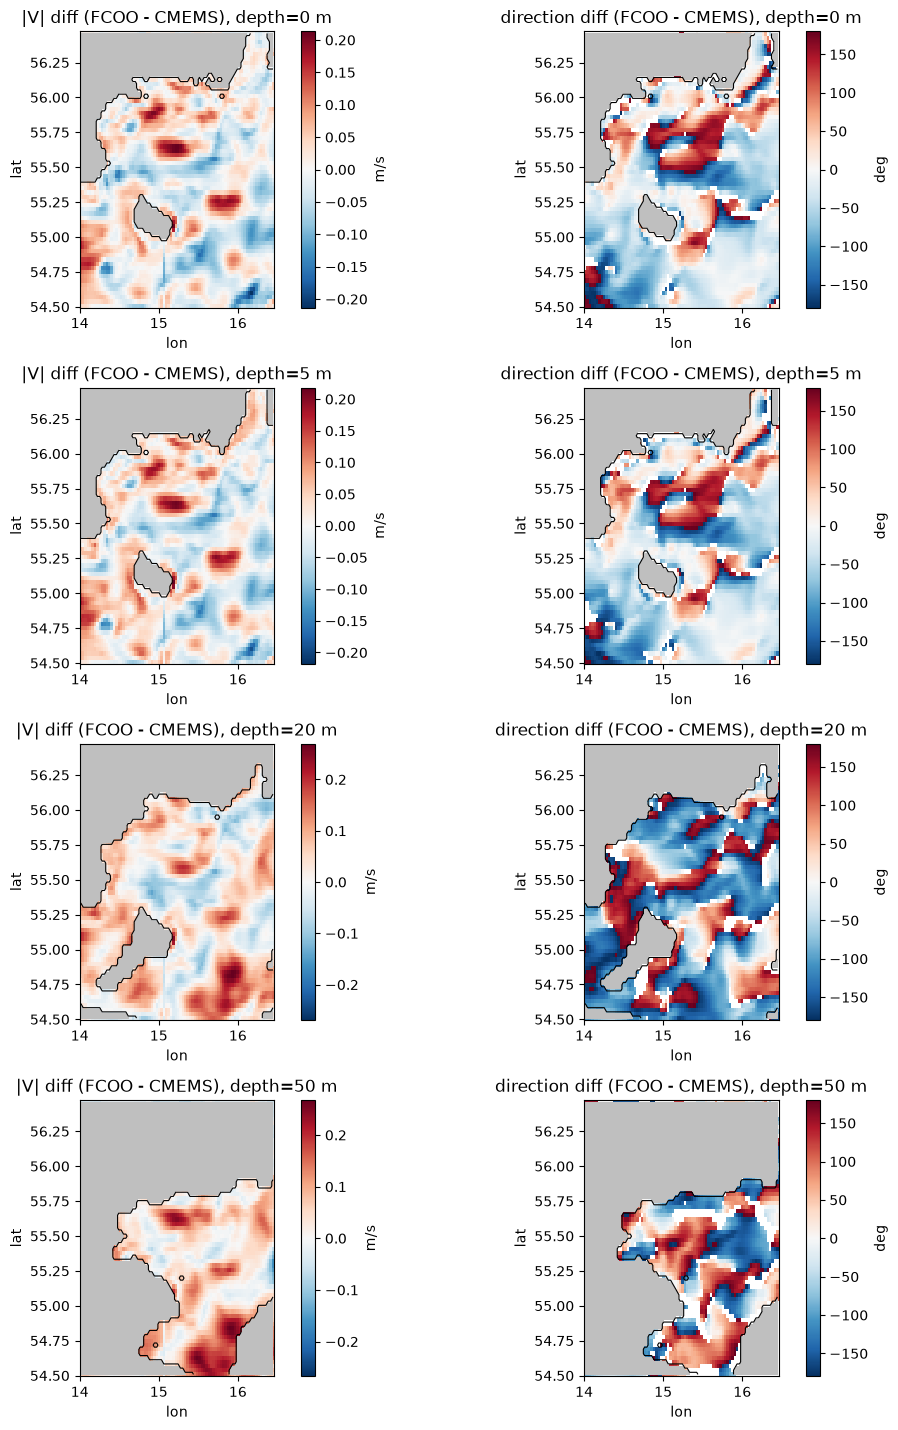

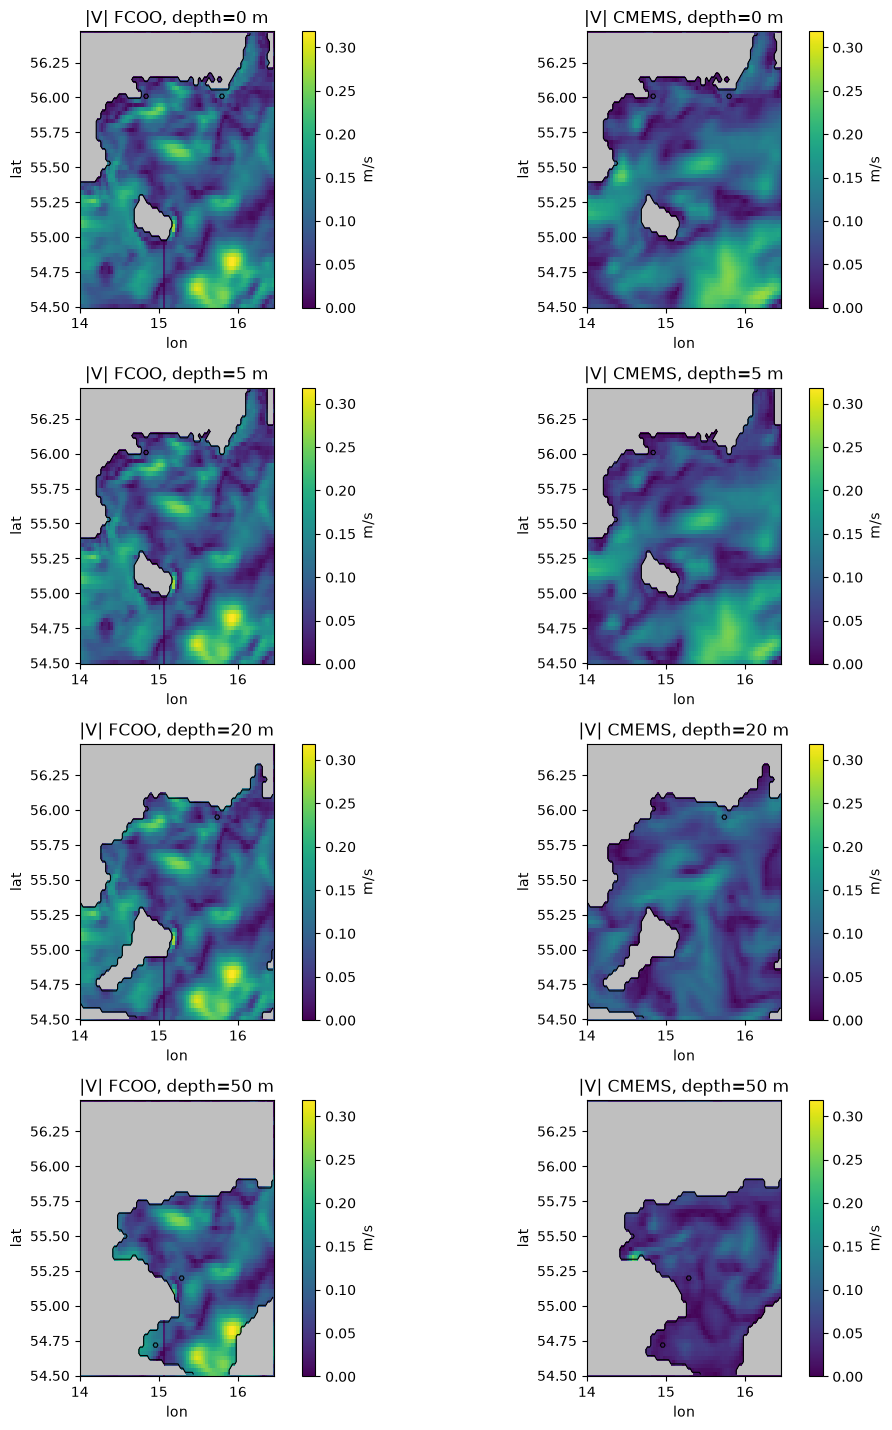

In [5]:
"""
compare_fcoo_cmems.py

Quick-look diagnostic comparing surface-current forecasts from an FCOO/GETM
.nc file against a CMEMS .nc file. For each requested depth, produces two
PNGs on a common lat/lon grid:
  - fcoo_vs_cmems_diff.png:  magnitude difference (|V_fcoo| - |V_cmems|)
    and direction difference (bearing_fcoo - bearing_cmems, wrapped to
    [-180, 180] deg).
  - fcoo_cmems_speed.png:    the raw |V| speed field for each model side
    by side, sharing one color scale per depth so they're directly
    comparable by eye.

Design notes / assumptions (edit the CONFIG block to match your files):
  - FCOO grids are often curvilinear (2D lat/lon). CMEMS grids are usually
    regular (1D lat/lon). This script treats both the same way: it flattens
    each source grid to scattered (lon, lat, value) points, optionally
    subsamples them, and interpolates onto one common coarse target grid
    with scipy.interpolate.griddata. The "coarse" knob is GRID_RES_DEG; the
    "not too much computation" knob is SOURCE_SUBSAMPLE_MAX_POINTS (the cost
    of griddata is driven by the *source* point count, not the target grid,
    so that's the one that actually controls runtime).
  - Depth: both models are interpolated (in the vertical) onto the same
    TARGET_DEPTHS, since native vertical levels rarely match between models.
    Assumes depth coordinates are positive-down in metres; if a file stores
    depth as negative (height), the sign is flipped automatically.
  - Time: the FCOO file's first timestep is used as the reference valid
    time, and the nearest available CMEMS timestep is matched to it. Set
    TARGET_TIME explicitly if you want a specific valid time instead.
  - Direction is undefined when currents are near zero, so direction-diff
    pixels are masked out wherever either model's speed at that point is
    below MIN_SPEED_FOR_DIRECTION.
  - Land/no-data overlay: regrid_layer() deliberately drops NaN source
    points before calling griddata, so the velocity fields it returns are
    smoothly interpolated *across* land (gaps get bridged by whichever sea
    points surround them) -- with no overlay you'd see fake "currents"
    painted straight over land. The land mask is built separately
    (regrid_mask) from each model's own NaN pattern at that depth, nearest-
    neighbour interpolated so the boundary stays sharp rather than fading,
    then unioned across both models (a cell is shown as land/no-data if
    EITHER model lacks data there) and grey-filled with a coastline drawn
    on top. Below the surface this also picks up bathymetry (cells too
    shallow to have water at that depth), not just literal coastline.

Run: python compare_fcoo_cmems.py
"""

import numpy as np
import xarray as xr
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ============================ CONFIG ============================
FCOO_FILE = "fcoo_subset.nc"
CMEMS_FILE = "cmems_subset.nc"

# Candidate variable/coord names to auto-detect. Add your own if these
# don't match -- print(xr.open_dataset(path)) once to check.
U_NAMES = ["uo", "u", "uu", "water_u", "eastward_sea_water_velocity"]
V_NAMES = ["vo", "v", "vv", "water_v", "northward_sea_water_velocity"]
LAT_NAMES = ["latitude", "lat", "nav_lat"]
LON_NAMES = ["longitude", "lon", "nav_lon"]
DEPTH_NAMES = ["depth", "lev", "z", "deptho"]
TIME_NAMES = ["time", "Time", "valid_time"]

TARGET_DEPTHS = [0.0, 5.0, 20.0, 50.0]   # metres, positive down
GRID_RES_DEG = 0.03                       # common output grid spacing (finer = more detail)
SOURCE_SUBSAMPLE_MAX_POINTS = 15000       # cap on source points per griddata call --
                                           # bumped up alongside GRID_RES_DEG: a finer
                                           # target grid only shows real extra detail if
                                           # there are enough source points behind it,
                                           # otherwise you're just smoothly interpolating
                                           # between the same sparse samples.
MIN_SPEED_FOR_DIRECTION = 0.02            # m/s; below this, direction is masked
TARGET_TIME = None                        # None -> FCOO's first timestep
RANDOM_SEED = 0                           # for reproducible subsampling

SHOW_LAND = True                          # overlay land / no-data areas + coastline
LAND_COLOR = "0.75"                       # grey fill for land/no-data cells
COASTLINE_COLOR = "black"
COASTLINE_LINEWIDTH = 0.8

OUTPUT_FILE_DIFF = "fcoo_vs_cmems_diff.png"
OUTPUT_FILE_SPEED = "fcoo_cmems_speed.png"
# ==================================================================


def find_name(ds, candidates, kind):
    for name in candidates:
        if name in ds.variables or name in ds.coords:
            return name
    raise KeyError(
        f"Could not find a {kind} variable in {list(ds.variables)}. "
        f"Tried: {candidates}. Add the real name to the matching *_NAMES list."
    )


def get_lonlat(ds, lat_name, lon_name):
    """Return lon, lat as arrays broadcast to the same (possibly 2D) shape."""
    lat = ds[lat_name].values
    lon = ds[lon_name].values
    if lat.ndim == 1 and lon.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)
    return lon, lat


def fix_depth_sign(da, depth_name):
    depth_vals = da[depth_name].values
    if np.nanmax(depth_vals) <= 0 and np.nanmin(depth_vals) < 0:
        da = da.assign_coords({depth_name: -depth_vals})
    return da


def interp_to_depths(da, depth_name, target_depths):
    """Interpolate onto target_depths, clamping requests outside the
    model's native depth range to the nearest available level (same
    out-of-bounds clamping pattern used elsewhere in the pipeline,
    rather than letting xarray return NaN for extrapolation)."""
    da = fix_depth_sign(da, depth_name)
    da = da.sortby(depth_name)
    d_min, d_max = float(da[depth_name].min()), float(da[depth_name].max())
    clamped = np.clip(target_depths, d_min, d_max)
    return da.interp({depth_name: clamped})


def regrid_layer(values, src_lon, src_lat, tlon, tlat, max_points, rng):
    values = np.asarray(values).ravel()
    src_lon = np.asarray(src_lon).ravel()
    src_lat = np.asarray(src_lat).ravel()

    good = np.isfinite(values) & np.isfinite(src_lon) & np.isfinite(src_lat)
    values, src_lon, src_lat = values[good], src_lon[good], src_lat[good]

    if values.size == 0:
        return np.full(tlon.shape, np.nan)

    if values.size > max_points:
        idx = rng.choice(values.size, size=max_points, replace=False)
        values, src_lon, src_lat = values[idx], src_lon[idx], src_lat[idx]

    pts = np.column_stack([src_lon, src_lat])
    out = griddata(pts, values, (tlon, tlat), method="linear")

    nan_mask = np.isnan(out)
    if nan_mask.any():
        out_nearest = griddata(pts, values, (tlon, tlat), method="nearest")
        out[nan_mask] = out_nearest[nan_mask]
    return out


def regrid_mask(values, src_lon, src_lat, tlon, tlat, max_points, rng):
    """Interpolate a binary data-present(1) / land-or-no-data(0) indicator
    onto the target grid via nearest-neighbour (a mask is categorical --
    blending it with 'linear' would invent fractional coastlines).
    Unlike regrid_layer, points are NOT dropped for having a NaN value --
    a NaN *is* the land signal we're trying to capture, so its coordinate
    has to stay in the source set with indicator=0."""
    values = np.asarray(values).ravel()
    src_lon = np.asarray(src_lon).ravel()
    src_lat = np.asarray(src_lat).ravel()

    coord_ok = np.isfinite(src_lon) & np.isfinite(src_lat)
    src_lon, src_lat = src_lon[coord_ok], src_lat[coord_ok]
    indicator = np.isfinite(values[coord_ok]).astype(float)

    if indicator.size > max_points:
        idx = rng.choice(indicator.size, size=max_points, replace=False)
        indicator, src_lon, src_lat = indicator[idx], src_lon[idx], src_lat[idx]

    pts = np.column_stack([src_lon, src_lat])
    return griddata(pts, indicator, (tlon, tlat), method="nearest")


def overlay_land(ax, tlon, tlat, land_mask):
    """Grey-fill land/no-data cells and draw a coastline contour over them,
    on top of whatever pcolormesh was already drawn on this axis."""
    if land_mask is None:
        return
    land_vals = np.where(land_mask, 1.0, np.nan)
    ax.contourf(tlon, tlat, land_vals, levels=[0.5, 1.5], colors=[LAND_COLOR], zorder=2)
    ax.contour(
        tlon, tlat, land_mask.astype(float), levels=[0.5],
        colors=COASTLINE_COLOR, linewidths=COASTLINE_LINEWIDTH, zorder=3,
    )


def bearing_deg(u, v):
    """Compass bearing (deg clockwise from North) the current flows toward."""
    return (90.0 - np.degrees(np.arctan2(v, u))) % 360.0


def angle_diff(a, b):
    """Smallest signed difference a-b, wrapped to [-180, 180] deg."""
    return (a - b + 180.0) % 360.0 - 180.0


def main():
    rng = np.random.default_rng(RANDOM_SEED)

    fcoo = xr.open_dataset(FCOO_FILE)
    cmems = xr.open_dataset(CMEMS_FILE)

    u_name_f, v_name_f = find_name(fcoo, U_NAMES, "u"), find_name(fcoo, V_NAMES, "v")
    lat_name_f, lon_name_f = find_name(fcoo, LAT_NAMES, "lat"), find_name(fcoo, LON_NAMES, "lon")
    depth_name_f = find_name(fcoo, DEPTH_NAMES, "depth")
    time_name_f = find_name(fcoo, TIME_NAMES, "time")

    u_name_c, v_name_c = find_name(cmems, U_NAMES, "u"), find_name(cmems, V_NAMES, "v")
    lat_name_c, lon_name_c = find_name(cmems, LAT_NAMES, "lat"), find_name(cmems, LON_NAMES, "lon")
    depth_name_c = find_name(cmems, DEPTH_NAMES, "depth")
    time_name_c = find_name(cmems, TIME_NAMES, "time")

    # --- pick matching valid time ---
    ref_time = fcoo[time_name_f].values[0] if TARGET_TIME is None else np.datetime64(TARGET_TIME)
    fcoo_t = fcoo.sel({time_name_f: ref_time}, method="nearest")
    cmems_t = cmems.sel({time_name_c: ref_time}, method="nearest")
    actual_f_time = fcoo_t[time_name_f].values
    actual_c_time = cmems_t[time_name_c].values
    print(f"Reference time: FCOO={actual_f_time}  CMEMS={actual_c_time}")

    # --- vertical interpolation onto common target depths ---
    u_f_da = interp_to_depths(fcoo_t[u_name_f], depth_name_f, TARGET_DEPTHS)
    v_f_da = interp_to_depths(fcoo_t[v_name_f], depth_name_f, TARGET_DEPTHS)
    u_c_da = interp_to_depths(cmems_t[u_name_c], depth_name_c, TARGET_DEPTHS)
    v_c_da = interp_to_depths(cmems_t[v_name_c], depth_name_c, TARGET_DEPTHS)

    # --- horizontal coords ---
    lon_f, lat_f = get_lonlat(fcoo_t, lat_name_f, lon_name_f)
    lon_c, lat_c = get_lonlat(cmems_t, lat_name_c, lon_name_c)

    # --- common coarse target grid (intersection of both domains) ---
    lon_min = max(np.nanmin(lon_f), np.nanmin(lon_c))
    lon_max = min(np.nanmax(lon_f), np.nanmax(lon_c))
    lat_min = max(np.nanmin(lat_f), np.nanmin(lat_c))
    lat_max = min(np.nanmax(lat_f), np.nanmax(lat_c))
    if lon_min >= lon_max or lat_min >= lat_max:
        raise ValueError("FCOO and CMEMS domains do not overlap -- check lon/lat ranges.")

    target_lon = np.arange(lon_min, lon_max, GRID_RES_DEG)
    target_lat = np.arange(lat_min, lat_max, GRID_RES_DEG)
    tlon, tlat = np.meshgrid(target_lon, target_lat)
    print(f"Target grid: {tlon.shape[1]} x {tlon.shape[0]} cells at {GRID_RES_DEG} deg")

    n_depths = len(TARGET_DEPTHS)
    fig_diff, axes_diff = plt.subplots(
        n_depths, 2, figsize=(11, 3.6 * n_depths), squeeze=False
    )
    fig_speed, axes_speed = plt.subplots(
        n_depths, 2, figsize=(11, 3.6 * n_depths), squeeze=False
    )

    aspect = 1.0 / np.cos(np.radians(np.nanmean([lat_min, lat_max])))

    for di, depth in enumerate(TARGET_DEPTHS):
        u_f_raw = u_f_da.isel({depth_name_f: di}).values
        v_f_raw = v_f_da.isel({depth_name_f: di}).values
        u_c_raw = u_c_da.isel({depth_name_c: di}).values
        v_c_raw = v_c_da.isel({depth_name_c: di}).values

        u_f = regrid_layer(u_f_raw, lon_f, lat_f, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        v_f = regrid_layer(v_f_raw, lon_f, lat_f, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        u_c = regrid_layer(u_c_raw, lon_c, lat_c, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
        v_c = regrid_layer(v_c_raw, lon_c, lat_c, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)

        if SHOW_LAND:
            # Derived straight from each model's own NaN pattern at this
            # depth -- so it's not just the coastline, it's "no data here"
            # in general (which below the surface also includes bathymetry:
            # cells too shallow to have water at this depth). A cell is
            # shown as land/no-data if EITHER model lacks data there.
            sea_f = regrid_mask(u_f_raw, lon_f, lat_f, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
            sea_c = regrid_mask(u_c_raw, lon_c, lat_c, tlon, tlat, SOURCE_SUBSAMPLE_MAX_POINTS, rng)
            land_mask = (sea_f < 0.5) | (sea_c < 0.5)
        else:
            land_mask = None

        mag_f, mag_c = np.hypot(u_f, v_f), np.hypot(u_c, v_c)
        mag_diff = mag_f - mag_c

        dir_f, dir_c = bearing_deg(u_f, v_f), bearing_deg(u_c, v_c)
        dir_diff = angle_diff(dir_f, dir_c)
        weak = (mag_f < MIN_SPEED_FOR_DIRECTION) | (mag_c < MIN_SPEED_FOR_DIRECTION)
        dir_diff = np.where(weak, np.nan, dir_diff)

        print(
            f"depth={depth:>5.1f} m | max|mag diff|={np.nanmax(np.abs(mag_diff)):.3f} m/s "
            f"| max|dir diff|={np.nanmax(np.abs(dir_diff)) if np.any(~np.isnan(dir_diff)) else float('nan'):.1f} deg"
        )

        # --- magnitude difference panel ---
        ax = axes_diff[di, 0]
        vmax_mag = np.nanmax(np.abs(mag_diff))
        vmax_mag = vmax_mag if vmax_mag > 0 else 1e-3
        im = ax.pcolormesh(
            tlon, tlat, mag_diff, cmap="RdBu_r",
            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_mag, vmax=vmax_mag),
            shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"|V| diff (FCOO - CMEMS), depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig_diff.colorbar(im, ax=ax, label="m/s")
        overlay_land(ax, tlon, tlat, land_mask)

        # --- direction difference panel ---
        ax = axes_diff[di, 1]
        im = ax.pcolormesh(
            tlon, tlat, dir_diff, cmap="RdBu_r",
            norm=TwoSlopeNorm(vcenter=0, vmin=-180, vmax=180),
            shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"direction diff (FCOO - CMEMS), depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig_diff.colorbar(im, ax=ax, label="deg")
        overlay_land(ax, tlon, tlat, land_mask)

        # --- absolute speed panels (shared color scale so the two models
        # are directly comparable by eye at this depth) ---
        speed_vmax = np.nanmax([np.nanmax(mag_f), np.nanmax(mag_c)])
        speed_vmax = speed_vmax if speed_vmax > 0 else 1e-3

        ax = axes_speed[di, 0]
        im = ax.pcolormesh(
            tlon, tlat, mag_f, cmap="viridis", vmin=0, vmax=speed_vmax, shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"|V| FCOO, depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig_speed.colorbar(im, ax=ax, label="m/s")
        overlay_land(ax, tlon, tlat, land_mask)

        ax = axes_speed[di, 1]
        im = ax.pcolormesh(
            tlon, tlat, mag_c, cmap="viridis", vmin=0, vmax=speed_vmax, shading="auto",
        )
        ax.set_aspect(aspect)
        ax.set_title(f"|V| CMEMS, depth={depth:g} m")
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        fig_speed.colorbar(im, ax=ax, label="m/s")
        overlay_land(ax, tlon, tlat, land_mask)

    fig_diff.tight_layout()
    fig_diff.savefig(OUTPUT_FILE_DIFF, dpi=150, bbox_inches="tight")
    print(f"Saved {OUTPUT_FILE_DIFF}")

    fig_speed.tight_layout()
    fig_speed.savefig(OUTPUT_FILE_SPEED, dpi=150, bbox_inches="tight")
    print(f"Saved {OUTPUT_FILE_SPEED}")


if __name__ == "__main__":
    main()